In [12]:
%load_ext autoreload
%autoreload 2
import kerasAC 
from kerasAC.generators.tiledb_generator import *
from kerasAC.tiledb_config import *

import tiledb 
gen=TiledbGenerator(batch_size=50,
                    ref_fasta="/mnt/data/GRCh38_no_alt_analysis_set_GCA_000001405.15.fasta",
                    tdb_array="/srv/scratch/annashch/encode_dnase_tiledb/db/histone",
                    chroms=['chr1'],
                    num_inputs=3,
                    num_outputs=2,
                    tdb_input_datasets=['seq','K562,K562','K562,K562'],
                    tdb_output_datasets=['K562,K562','K562,K562'],
                    tdb_input_source_attribute=['seq','control_count_bigwig_plus_5p,control_count_bigwig_minus_5p','control_count_bigwig_plus_5p,control_count_bigwig_minus_5p'],
                    tdb_output_source_attribute=['count_bigwig_plus_5p,count_bigwig_minus_5p','count_bigwig_plus_5p,count_bigwig_minus_5p'],
                    tdb_input_flank=['3000','500,500','500,500'],
                    tdb_output_flank=['500,500','500,500'],
                    tdb_input_min=['None', 'None,None', 'None,None'], 
                    tdb_output_min=['None,None', 'None,None'],
                    tdb_input_max=['None','None,None','None,None'],
                    tdb_output_max=['None,None','None,None'],
                    tdb_input_aggregation=['None','None,None','sum,sum'],
                    tdb_input_transformation=['None','None,None','log,log'],
                    tdb_output_aggregation=['None,None','sum,sum'],
                    tdb_output_transformation=['None,None','log,log'],
                    tdb_partition_attribute_for_upsample='overlap_peak',
                    tdb_partition_thresh_for_upsample=1,
                    tdb_partition_datasets_for_upsample=['K562'],
                    upsample_ratio=1.0,
                    shuffle_epoch_start=True,
                    shuffle_epoch_end=True,
                    return_coords=True,
                    tdb_config=get_default_config(),
                    tdb_ctx=tiledb.Ctx(config=get_default_config()),
                    num_threads=24,
                    add_revcomp=True)
                   

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
opening:/srv/scratch/annashch/encode_dnase_tiledb/db/histone for reading...
success!
got indices for used chroms
identified input dataset indices:[[], [0, 0], [0, 0]]
identified output dataset indices:[[0, 0], [0, 0]]
identified upsampling dataset indices:[0]
num_threads:24
starting getting indices to upsample in range:0-248956422
finished indices to upsample in range:0-248956422
closed upsampling pool
made upsampled index data frame
shuffling upsampled dataframes prior to start of training
finished upsampling
created generator


In [42]:
gen.num_indices

248956422

In [43]:
gen.upsampled_indices_len

5185655

In [44]:
(X,y,coords)=gen[0]

In [84]:
X[2].dtype

dtype('float32')

In [46]:
import matplotlib 
import matplotlib.pyplot as plt 

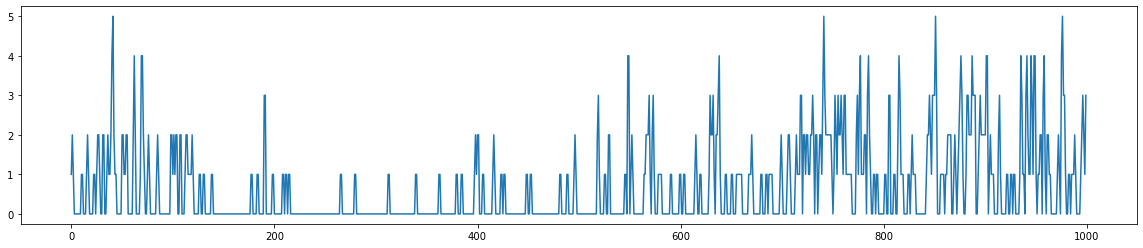

In [50]:
plt.figure(figsize=(20,4))
plt.plot(y[0][0,:,1])

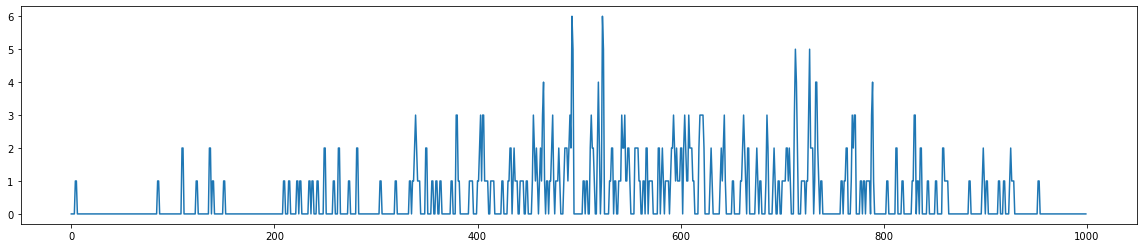

In [79]:
plt.figure(figsize=(20,4))

plt.plot(y[0][0,:,0])

In [40]:
15835291-500

15834791

In [41]:
15835291+500

15835791

In [13]:
import argparse
from kerasAC.architectures.profile_bpnet_chipseq import * 
from kerasAC import config
args={} 
args['seed']=1234
args['tdb_input_flank']=['3000','500,500','500,500']
args['tdb_output_flank']=['500,500','500,500']
args['num_tasks']=2
args['model_params']='params.txt'
args=config.args_object_from_args_dict(args)
model=getModelGivenModelOptionsAndWeightInits(args)

params:
filters:300
n_dil_layers:10
conv1_kernel_size:21
profile_kernel_size:75
counts_loss_weight:25.0
profile_loss_weight:1.0
6000
1000
got model
compiled model


In [14]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
sequence (InputLayer)           (None, 6000, 4)      0                                            
__________________________________________________________________________________________________
1st_conv (Conv1D)               (None, 5980, 300)    25500       sequence[0][0]                   
__________________________________________________________________________________________________
1stconv-crop_1th_dconv (Croppin (None, 5976, 300)    0           1st_conv[0][0]                   
__________________________________________________________________________________________________
0_dilconv (Conv1D)              (None, 5976, 300)    270300      1st_conv[0][0]                   
____________________________________________________________________________________________

In [55]:
preds=model.predict(X)

In [73]:
np.mean((np.square(preds[1] - y[1])).mean(axis=0))

13.773031

In [65]:
13.487759590148926*2

26.97551918029785

In [69]:
from kerasAC.custom_losses import * 
multinomial_nll(y[0][:,:,0],preds[0][:,:,0])

<tf.Tensor: shape=(), dtype=float32, numpy=552.294>

In [70]:
multinomial_nll(y[0][:,:,1],preds[0][:,:,1])

<tf.Tensor: shape=(), dtype=float32, numpy=560.97327>

In [71]:
552.294+560.97

1113.2640000000001

In [77]:
model.evaluate(x=X,y=y)



50/50 [==============================] - 0s 7ms/step


[1457.59302734375, 1138.1541748046875, 13.487759590148926]

In [72]:
model.metrics_names

['loss', 'profile_predictions_loss', 'logcount_predictions_loss']